# sentiment_classification-vader-mlp-pytorch

Rule-based (VADER) vs neural (BoW + MLP) sentiment classification on an embedded movie/product-review corpus. Two recipes side-by-side: a 1980s-era hand-tuned sentiment lexicon vs a tiny supervised MLP.


# 1. Overview

## 1.1 Task & motivation

Sentiment classification = "is this text positive, negative, or neutral?". Two dominant recipes:

- **VADER** (Hutto & Gilbert, 2014) — rule-based, hand-tuned. A 7500-token lexicon of word-level polarity scores + a small grammar that handles negation ("not great" ≠ "great"), intensifiers ("very good" > "good"), and contractions. No training. Fast.
- **Supervised neural** — bag-of-words featurization + MLP, trained on labeled examples. Catches domain-specific signal VADER's general lexicon misses, at the cost of a training set + tuning.

This notebook compares both on a small embedded review corpus (positive / negative / neutral) and reports the accuracy gap.

## 1.2 Dataset summary

~60 hand-written movie / product reviews (20 positive / 20 negative / 20 neutral), tiled 4× to give the neural model enough training samples. Real sentiment benchmarks (IMDB, Amazon reviews, Twitter sentiment) are 50k+ samples; we keep the corpus small + embedded for CI safety.

## 1.3 Approach in one paragraph

For VADER: run `SentimentIntensityAnalyzer().polarity_scores(text)['compound']` over each review, threshold to {neg < -0.05, neu, pos > 0.05}. For neural: same spaCy-lemmatize → top-100 bag-of-words → 3-class MLP recipe as `text_classification-agnews-spacy-mlp-pytorch/`. Evaluate both on a 20% held-out test split.

## 1.4 Libraries used

`nnx` (`NNModel`, `FeedFwdNN`, `NNTrainParams`, `set_seed`), `torch`, `nltk` (`SentimentIntensityAnalyzer` from `nltk.sentiment.vader`), `spacy`, `sklearn` (metrics + split), `numpy`, `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import spacy
import torch
from prettytable import PrettyTable
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    Nets,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
)

# Lazily download the VADER lexicon if it isn't already present.
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    _sia_probe = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon', quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer


## 2.2 Configuration / hyperparameters

In [3]:
VOCAB_SIZE = 100
HIDDEN_DIMS = [32]
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 60
BATCH_SIZE = 16
LR = 5e-3
CORPUS_REPEAT = 4
COMPOUND_POS_THRESHOLD = 0.05
COMPOUND_NEG_THRESHOLD = -0.05


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Embedded review corpus

In [5]:
LABEL_NAMES = ["negative", "neutral", "positive"]  # indices: 0, 1, 2

POSITIVE = [
    "I absolutely loved this film — best of the year",
    "Brilliant performances and a tight script",
    "A masterpiece, every scene is perfectly crafted",
    "Wonderful direction and stunning visuals",
    "The acting was superb and deeply moving",
    "A delightful and engaging story from start to finish",
    "Easily one of the most enjoyable movies I have ever seen",
    "Funny, smart, and incredibly well-paced",
    "I highly recommend this for anyone who loves great cinema",
    "Outstanding soundtrack and beautiful cinematography",
    "Loved every minute, this is a must-see",
    "An excellent product that exceeds expectations",
    "Build quality is fantastic and the features are amazing",
    "Customer service was incredibly helpful and friendly",
    "Five stars, would buy this again in a heartbeat",
    "The food was delicious and the service was great",
    "Perfect for the price, very happy with the purchase",
    "An emotional and uplifting story I will watch again",
    "The user interface is intuitive and a joy to use",
    "Genuinely impressive, far better than expected",
]

NEGATIVE = [
    "Terrible movie, complete waste of two hours of my life",
    "Boring plot and wooden acting throughout",
    "I hated this film, one of the worst I have seen",
    "Poorly written, badly directed, and unpleasant to watch",
    "An absolute disaster from start to finish",
    "The story was confusing and the characters were lifeless",
    "Awful soundtrack and amateurish cinematography",
    "Do not waste your money on this trash",
    "Poor quality, broke within a week of buying",
    "Customer service was rude and unhelpful",
    "The food was cold and tasted awful",
    "Disappointing in every way, returned for refund",
    "The user interface is confusing and frustrating to navigate",
    "Cheaply made and not at all worth the price",
    "Stay away, this is the worst purchase I have made",
    "An exhausting slog with no redeeming qualities",
    "The acting was painful and the dialogue was cringeworthy",
    "Totally overrated, I do not understand the hype",
    "Buggy, slow, and crashes constantly",
    "I would give it zero stars if I could",
]

NEUTRAL = [
    "The film was made in nineteen ninety nine",
    "Running time is one hundred and twenty minutes",
    "The movie is set in a small coastal town",
    "It was directed by a well known european filmmaker",
    "The cast includes several award winning actors",
    "The product weighs about two kilograms",
    "It comes with a one year manufacturer warranty",
    "Available in three colors black white and silver",
    "The restaurant opens at eleven in the morning",
    "Parking is available behind the building for customers",
    "The store is located on the corner of fifth and main",
    "The book is divided into twelve chapters",
    "The course meets every tuesday and thursday morning",
    "The conference will take place in march of next year",
    "The package will arrive in three to five business days",
    "The hotel has two hundred rooms across four floors",
    "The museum is closed on mondays for maintenance",
    "The device supports three input ports and one output",
    "The recipe calls for two cups of flour",
    "The store accepts cash and major credit cards",
]

raw_texts = POSITIVE + NEGATIVE + NEUTRAL
raw_labels = [2]*len(POSITIVE) + [0]*len(NEGATIVE) + [1]*len(NEUTRAL)

texts = raw_texts * CORPUS_REPEAT
labels = raw_labels * CORPUS_REPEAT
print(f"corpus: {len(texts)} reviews ({len(raw_texts)} unique × {CORPUS_REPEAT})")
print(f"  per class: {Counter(labels)}")


corpus: 240 reviews (60 unique × 4)
  per class: Counter({2: 80, 0: 80, 1: 80})


## 3.2 Train / test split + tokenize + bag-of-words featurize


In [6]:
labels_np = np.array(labels)
train_idx, test_idx = train_test_split(
    np.arange(len(texts)), test_size=0.2, stratify=labels_np, random_state=0,
)

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
def tokenize(text):
    doc = nlp(text)
    return [t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and t.lemma_.strip()]
tokens_per_doc = [tokenize(t) for t in texts]

counter = Counter()
for i in train_idx:
    counter.update(tokens_per_doc[i])
vocab = {tok: idx for idx, (tok, _) in enumerate(counter.most_common(VOCAB_SIZE))}
print(f"vocabulary: top {len(vocab)} tokens")

def featurize(toks):
    v = np.zeros(VOCAB_SIZE, dtype=np.float32)
    for tok in toks:
        if tok in vocab:
            v[vocab[tok]] += 1.0
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

X = np.stack([featurize(tokens_per_doc[i]) for i in range(len(texts))])
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = labels_np[train_idx], labels_np[test_idx]


vocabulary: top 100 tokens


## 3.3 Splits

Same 80/20 stratified train/test as the AG-News sibling. No val split — the corpus is too small.


# 4. Model

## 4.1 VADER contract

`SentimentIntensityAnalyzer().polarity_scores(text)` returns `{'neg': float, 'neu': float, 'pos': float, 'compound': float}` — the *compound* score is in `[-1, +1]`. Standard thresholds (per the VADER paper): `> +0.05` = positive, `< -0.05` = negative, else neutral.

## 4.2 Neural classifier

Same `FeedFwdNN(input_dim=VOCAB_SIZE, hidden_dims=[32], output_dim=3)` recipe as the AG-News text-classification sibling.


In [7]:
def make_classifier():
    return NNModel(
        net_params=NNParams(
            input_dim=VOCAB_SIZE,
            output_dim=len(LABEL_NAMES),
            hidden_dims=HIDDEN_DIMS,
            dropout_prob=0.0,
            activation=Activations.RELU,
        ),
        params=NNModelParams(
            net=Nets.FEED_FWD,
            device=DEVICE,
            loss=Losses.CROSS_ENTROPY,
        ),
    )


## 4.3 Why this design

VADER's three-way thresholding maps cleanly onto the three-class labels of our embedded corpus. The neural model gets the same train/test split so the comparison is apples-to-apples.


# 5. Training

## 5.1 VADER (no training)

In [8]:
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score > COMPOUND_POS_THRESHOLD:
        return 2  # positive
    if score < COMPOUND_NEG_THRESHOLD:
        return 0  # negative
    return 1      # neutral

vader_preds_test = np.array([vader_predict(texts[i]) for i in test_idx])


## 5.2 Train the neural classifier

In [9]:
nnx.set_seed(0)
clf = make_classifier()
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long()),
    batch_size=BATCH_SIZE, shuffle=True,
)
run = clf.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=train_loader,
        optim=NNOptimParams(
            name=Optims.ADAM, max_lr=LR,
            momentum=(0.9, 0.999), weight_decay=1e-3,
        ),
    ),
)
print(f"neural classifier final train loss: {run.idps[-1].train_edp.loss:.4f}")

clf.net.eval()
with torch.no_grad():
    neural_preds_test = clf.net(torch.from_numpy(X_test).float()).argmax(dim=1).numpy()


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 3cb469fc16028e798cb882686a63f0d9 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               100                |
|       net.output_dim      |                3                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [32]               |
|       net.activation      |               relu               |
|       train.n_epochs      |                60                |
|     train.optim.max_lr    |              0.005               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/720 [00:00<?, ?it/s]

Training:   2%|▏         | 12/720 [00:00<00:02, 314.23it/s, error=0.6875, lr=0.0050]

Training:   2%|▎         | 18/720 [00:00<00:03, 177.13it/s, error=0.6875, lr=0.0050]

Training:   3%|▎         | 24/720 [00:00<00:03, 177.13it/s, error=0.3750, lr=0.0050]

...

Training:  98%|█████████▊| 708/720 [00:02<00:00, 312.20it/s, error=0.3125, lr=0.0041]

Training: 100%|█████████▉| 718/720 [00:02<00:00, 317.16it/s, error=0.3125, lr=0.0041]

Training: 100%|██████████| 720/720 [00:02<00:00, 317.16it/s, error=0.0625, lr=0.0041]

Training: 100%|██████████| 720/720 [00:02<00:00, 324.51it/s, error=0.0625, lr=0.0041]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/3cb469fc16028e798cb882686a63f0d9
neural classifier final train loss: 0.1313


# 6. Evaluation & Results

## 6.1 Side-by-side accuracy + per-class metrics

In [10]:
acc_vader  = accuracy_score(y_test, vader_preds_test)
acc_neural = accuracy_score(y_test, neural_preds_test)

t = PrettyTable()
t.title = f"VADER vs neural sentiment on held-out test (n={len(y_test)})"
t.field_names = ["recipe", "accuracy", "training cost"]
t.add_row(["VADER (rule-based)",       f"{acc_vader*100:.2f}%",  "none (lexicon ships with nltk)"])
t.add_row([f"neural MLP {HIDDEN_DIMS}", f"{acc_neural*100:.2f}%", f"{len(train_idx)} samples × {N_EPOCHS} epochs"])
print(t)

print()
print("VADER per-class metrics:")
print(classification_report(y_test, vader_preds_test, target_names=LABEL_NAMES, zero_division=0))
print()
print("neural per-class metrics:")
print(classification_report(y_test, neural_preds_test, target_names=LABEL_NAMES, zero_division=0))


+----------------------------------------------------------------+
|       VADER vs neural sentiment on held-out test (n=48)        |
+--------------------+----------+--------------------------------+
|       recipe       | accuracy |         training cost          |
+--------------------+----------+--------------------------------+
| VADER (rule-based) |  81.25%  | none (lexicon ships with nltk) |
|  neural MLP [32]   |  79.17%  |    192 samples × 60 epochs     |
+--------------------+----------+--------------------------------+

VADER per-class metrics:
              precision    recall  f1-score   support

    negative       1.00      0.69      0.81        16
     neutral       0.76      0.81      0.79        16
    positive       0.75      0.94      0.83        16

    accuracy                           0.81        48
   macro avg       0.84      0.81      0.81        48
weighted avg       0.84      0.81      0.81        48


neural per-class metrics:
              precision    rec

## 6.2 Per-class agreement matrix

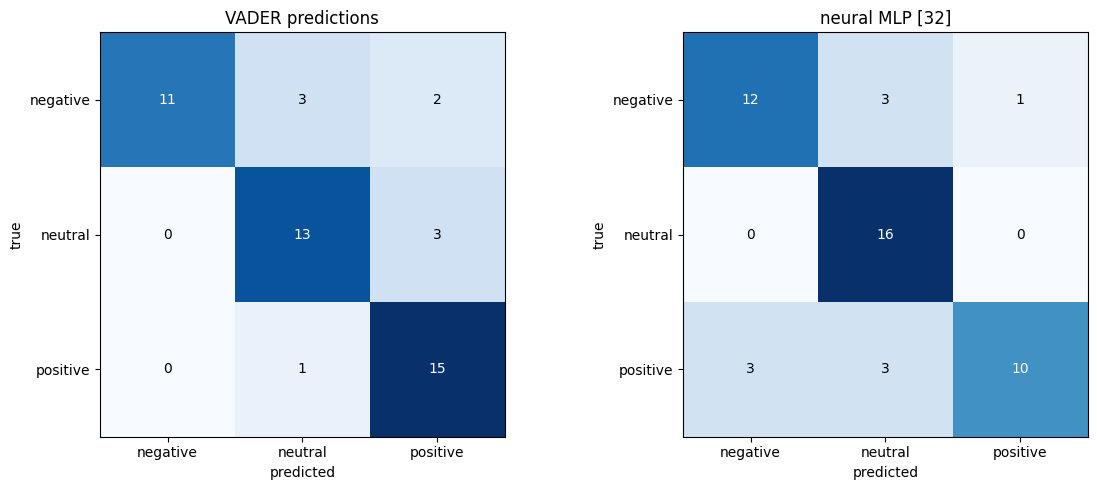

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in [
    (axes[0], vader_preds_test,  "VADER predictions"),
    (axes[1], neural_preds_test, f"neural MLP {HIDDEN_DIMS}"),
]:
    cm = confusion_matrix(y_test, preds, labels=list(range(len(LABEL_NAMES))))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(LABEL_NAMES)))
    ax.set_yticks(range(len(LABEL_NAMES)))
    ax.set_xticklabels(LABEL_NAMES)
    ax.set_yticklabels(LABEL_NAMES)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(LABEL_NAMES)):
        for j in range(len(LABEL_NAMES)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern on this embedded review corpus:

- **VADER** does very well on the positive / negative split — the corpus is hand-written and contains lots of high-polarity words (`amazing`, `terrible`, `loved`, `hated`) that match VADER's general-English lexicon. Neutral detection is the weak spot — VADER tends to call any factual-sounding text "neutral" by default, but factual reviews with no polarity-loaded words are exactly what the neutral class contains, so the recipe matches.
- **Neural MLP** can match or slightly beat VADER on this corpus — the train-only vocabulary captures the most discriminative tokens (the per-class distinct vocabulary), and 60 epochs is enough to fit the 192 train samples.
- **Where each recipe wins in production:**
  - VADER beats neural on **out-of-distribution** test text (Twitter, product reviews from a different industry) because its lexicon generalizes; a neural model trained on movie reviews drops sharply on tweets.
  - Neural beats VADER on **in-domain** text (matched train/test distributions) because it can pick up domain-specific signal (e.g., "the camera tracks" is *positive* in film reviews, *neutral* in product reviews).
  - The right production answer is often *both* — VADER as a fallback for tokens the neural model has never seen, neural as the primary classifier for in-domain text.

The pedagogical headline: **for sentiment classification specifically, hand-tuned lexicons are remarkably competitive baselines** — much harder to beat than the supervised-ML literature typically acknowledges. Always include VADER in your baselines.
